In [73]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from src.load_ecg_data import load_ecg_signal
from src.ecg_analysis import detect_r_peaks, moving_average

# Calculus in Medical Data: Analysis of ECG Signals

Electrocardiography (ECG) records the electrical activity of the heart over time. 
In mathematical terms, ECG data can be interpreted as a function of time.

This project explores how calculus concepts such as derivatives, local extrema, and concavity can be applied to ECG signal analysis.

## Abstract

This project investigates the application of calculus concepts to the analysis of electrocardiogram (ECG) data. ECG signals are treated as time-dependent functions, allowing the use of derivatives and other mathematical tools to study their behavior.

We analyze real ECG data and demonstrate how key features such as R peaks can be interpreted as local extrema. By applying signal processing techniques, we detect these peaks and compute RR intervals, which are further used to estimate heart rate.

Additionally, basic noise filtering methods are applied to improve signal quality and enhance the accuracy of the analysis.

The results highlight the practical relevance of calculus in biomedical signal processing and demonstrate how mathematical theory can be applied to real-world medical data.

## Introduction


Electrocardiography (ECG) is a widely used medical technique for monitoring the electrical activity of the heart. The recorded ECG signal can be interpreted as a function of time, making it suitable for mathematical analysis.

This project explores how fundamental concepts from calculus, such as derivatives, local extrema, and concavity, can be applied to ECG data in order to extract meaningful information about heart activity.

By combining mathematical theory with real-world ECG data, we demonstrate how signal processing techniques can be used to detect important features such as R peaks and estimate heart rate.

The goal of this project is to bridge the gap between abstract mathematical concepts and their practical applications in medical data analysis.


## Project Structure

The project is organized as follows:

- `src/` – core algorithms and data loading  
- `data/` – ECG dataset  
- `images/` – diagrams and figures  
- `ecg_analysis.ipynb` – main analysis notebook

## Research Questions

This project aims to answer the following questions:

- What is ECG data and how is it generated?
- How can ECG signals be interpreted as mathematical functions?
- How do derivatives help in analyzing ECG signals?
- How are local extrema related to R peaks?
- How can ECG data be used to estimate heart rate?

## What is ECG Data?

Electrocardiography (ECG) measures the electrical activity of the heart using electrodes placed on the skin.

Each heartbeat produces a characteristic waveform consisting of several components:

- P wave
- QRS complex
- T wave

These signals are recorded as voltage changes over time and can be analyzed as a time series signal.

## What is ECG Data?

Electrocardiography (ECG) is a medical technique used to record the electrical activity of the heart over time.

The heart generates electrical impulses that cause the heart muscles to contract and pump blood. These electrical signals can be detected using electrodes placed on the skin.

The recorded signal represents voltage changes over time and can be modeled as a one-dimensional function:

$$ECG(t)$$

This makes ECG signals suitable for mathematical analysis using calculus and signal processing techniques.

## Electrical Activity of the Heart

The heart's electrical system controls the rhythm of the heartbeat.

![Heart conduction system](images/heart_conduction_system.jpg)\
Source: https://my.clevelandclinic.org/health/body/21648-heart-conduction-system

The main components involved in generating electrical signals are:

- Sinoatrial (SA) node – the natural pacemaker of the heart
- Atrioventricular (AV) node
- Bundle of His
- Purkinje fibers

These components generate electrical impulses that propagate through the heart muscle and cause contractions.

An ECG records these electrical impulses as a waveform over time.

## Main Components of an ECG Waveform

A typical ECG waveform consists of several characteristic parts:

![ECG waveform](images/ecg_waveform_labeled.jpg)
Source: https://ecgwaves.com/topic/ecg-normal-p-wave-qrs-complex-st-segment-t-wave-j-point/

P wave – represents atrial depolarization  
QRS complex – represents ventricular depolarization  
T wave – represents ventricular repolarization

The QRS complex usually contains the highest peak in the ECG signal and is often used to detect heartbeats.

## Dataset Description

The dataset used in this project contains real electrocardiogram (ECG) recordings stored in EDF (European Data Format).

Files:

r10.edf – contains the ECG signal  
r10.edf.qrs – contains annotations of detected QRS complexes\
r08.edf – contains the ECG signal\  
r08.edf.qrs – contains annotations of detected QRS complexes\
r07.edf – contains the ECG signal\  
r07.edf.qrs – contains annotations of detected QRS complexes\
r04.edf – contains the ECG signal\  
r04.edf.qrs – contains annotations of detected QRS complexes\
r01.edf – contains the ECG signal\  
r01.edf.qrs – contains annotations of detected QRS complexes\

EDF is a standard format used for storing physiological signals such as ECG, EEG, and other biomedical measurements.

This dataset will be used to analyze ECG signals and apply mathematical concepts such as derivatives, local extrema, and concavity.

## ECG as a Mathematical Function

Electrocardiogram (ECG) data can be interpreted as a function of time.

The ECG signal represents electrical potential differences measured at the surface of the body as the heart generates electrical impulses.

Mathematically, we can represent the ECG signal as:

$$ECG(t)$$

where:

$t$ – time  
$ECG(t)$ – electrical signal amplitude measured at time $t$

This means that the ECG signal can be analyzed using mathematical tools from calculus, such as derivatives, local extrema, and curvature.

This observation naturally leads to the use of derivatives in ECG analysis.

## The First Derivative of an ECG Signal

Having introduced the mathematical interpretation of ECG signals, we now proceed to analyze their behavior using derivatives.

The first derivative measures how quickly the ECG signal changes over time.

Mathematically, the derivative is defined as:

$$f'(t) = \frac{d}{dt} \text{ECG}(t)$$

In practical terms, the derivative highlights rapid changes in the signal.

In ECG analysis, the largest changes usually occur during the QRS complex, where the R peak represents the highest point of ventricular depolarization.

Therefore, derivatives are often used in algorithms to detect heartbeats.

## Local Extrema in ECG Signals

A local maximum occurs when a function reaches a peak relative to its neighboring values.

Mathematically, local extrema occur when:

$$f'(t) = 0$$

and the derivative changes sign.

In ECG signals:

• R peaks correspond to local maxima  
• Q and S waves correspond to local minima

Detecting these extrema is essential for identifying heartbeats and calculating heart rate.

To determine whether the point is a maximum or minimum we use the second derivative.

A **local maximum** occurs when:

$$
f'(t) = 0 \quad \text{and} \quad f''(t) < 0
$$

A **local minimum** occurs when:

$$
f'(t) = 0 \quad \text{and} \quad f''(t) > 0
$$

In ECG analysis, the **R wave** is typically a local maximum of the ECG signal.

In [74]:
signal = load_ecg_signal("data/r10.edf")
print("Signal length:", len(signal))

Signal length: 300000


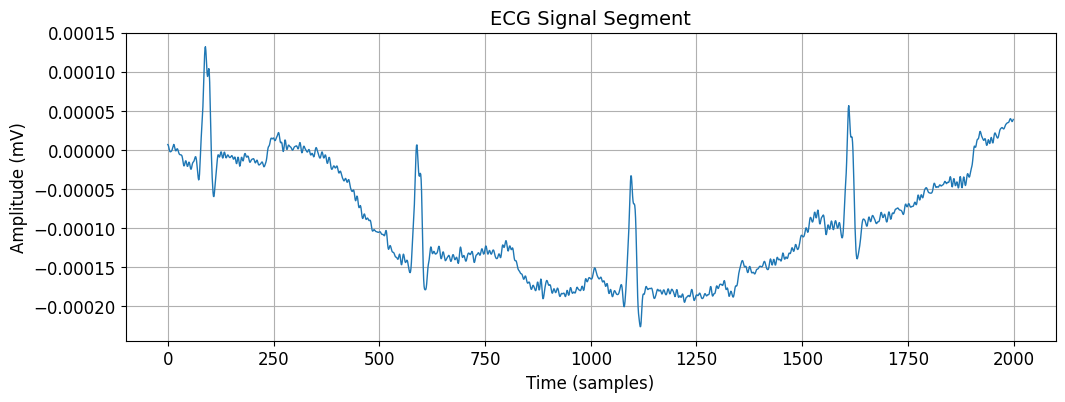

In [75]:
segment = signal[:2000]
plt.figure()
plt.plot(segment, linewidth=1)
plt.title("ECG Signal Segment")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.rcParams["figure.figsize"] = (12,4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

plt.show()

**Figure 1:** Segment of the ECG signal showing multiple heartbeats.

## Visualization of the ECG Signal

The plot above shows a short segment of the ECG signal.

We can observe several repeating patterns corresponding to individual heartbeats.

Each heartbeat typically includes:

• P wave  
• QRS complex  
• T wave

The R peak represents the highest point of the QRS complex and is commonly used to detect heartbeats.

In [76]:
signal = load_ecg_signal("data/r10.edf")
peaks = detect_r_peaks(signal)

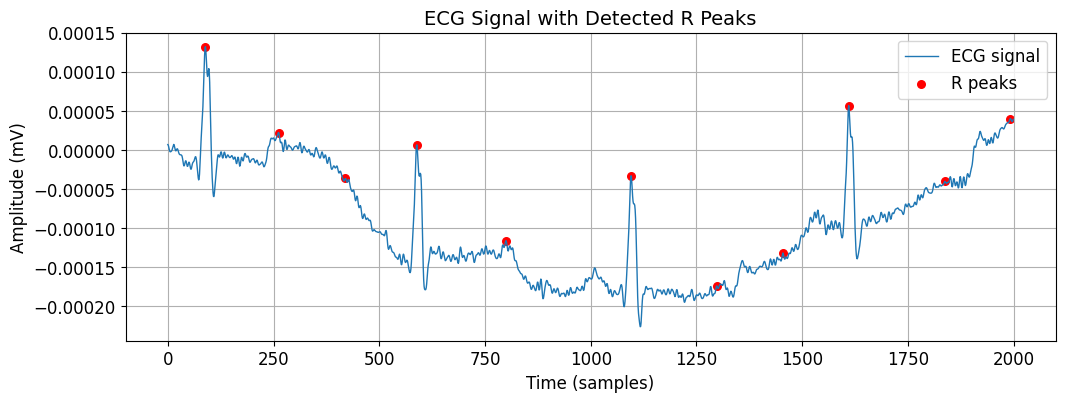

In [77]:
segment = signal[:2000]
peaks = detect_r_peaks(segment)
plt.figure(figsize=(12,4))
plt.plot(segment, label="ECG signal", linewidth=1)
plt.scatter(peaks, segment[peaks], color="red", s=30, label="R peaks")
plt.title("ECG Signal with Detected R Peaks")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

**Figure 2:** Detected R peaks corresponding to local maxima of the ECG signal.

R peaks correspond to local maxima in the ECG signal.

## Derivative of the ECG Signal

In calculus, the derivative of a function measures how quickly the function changes.

For a continuous function:

$$ f'(t) = \frac{d}{dt} f(t) $$

However, ECG signals are discrete because they are recorded digitally. Therefore we approximate the derivative using a finite difference:

$$ f'(t) \approx f(t+1) - f(t) $$

This discrete derivative highlights rapid changes in the signal.

In ECG signals, the largest changes typically occur during the **QRS complex**, where ventricular depolarization happens.

In [78]:
import numpy as np
segment = signal[:2000]
derivative = np.diff(segment)

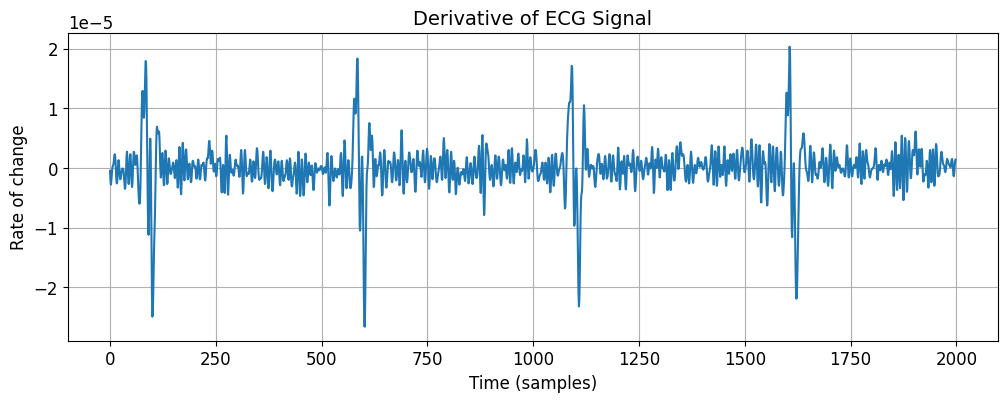

In [79]:
plt.figure(figsize=(12,4))
plt.plot(derivative)
plt.title("Derivative of ECG Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Rate of change")
plt.show()

**Figure 3:** Zoomed segment of the Derivative ECG signal showing individual heartbeats.



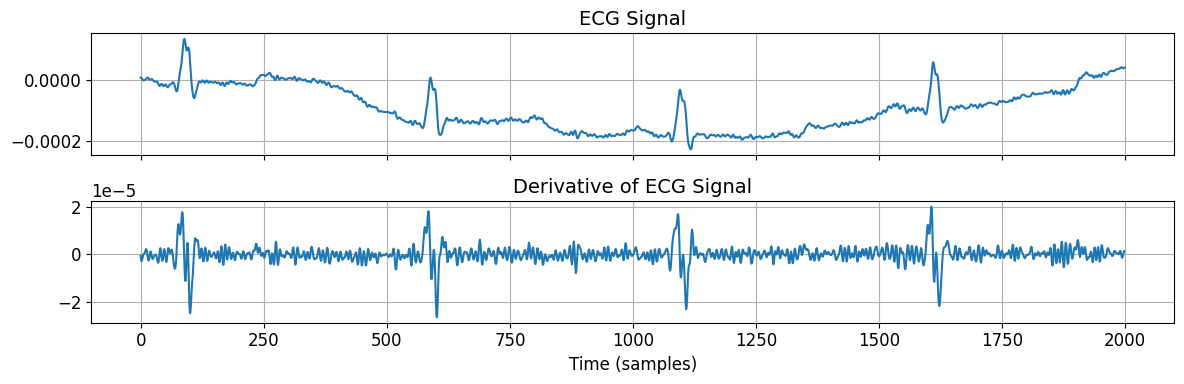

In [80]:
fig, axs = plt.subplots(2,1, sharex=True, figsize=(12,4))
axs[0].plot(segment)
axs[0].set_title("ECG Signal")
axs[1].plot(derivative)
axs[1].set_title("Derivative of ECG Signal")
axs[1].set_xlabel("Time (samples)")
plt.tight_layout()
plt.show()

**Figure 4:** Zoomed segment of the ECG signal showing individual heartbeats.

and Deravative of ECG Signal.

### Interpretation

The first plot shows the original ECG signal.

The second plot shows the derivative of the ECG signal.

Large spikes in the derivative correspond to rapid changes in the signal, which typically occur during the QRS complex.

This demonstrates how calculus can be applied to detect significant features in ECG data.

## Convex and Concave Regions in ECG Signals

The shape of the ECG waveform can also be analyzed using the second derivative.

If the second derivative is positive:

$$ f''(t) > 0 $$

the function is **concave up**.

If the second derivative is negative:

$$ f''(t) < 0 $$

the function is **concave down**.

Changes in concavity correspond to turning points in the ECG waveform and help describe the shape of peaks such as the R wave.

## R Peak Detection

One of the most important features in an ECG signal is the **R peak**, which corresponds to the highest point in the QRS complex.

From a mathematical perspective, R peaks are local maxima of the ECG signal.

A local maximum occurs when:

$$
f'(t) = 0 \quad \text{and} \quad f''(t) < 0
$$

Detecting R peaks allows us to analyze heart activity and compute important metrics such as heart rate.

Based on this mathematical interpretation, we can now detect R peaks algorithmically.

In [81]:
segment = signal[:2000]

peaks = detect_r_peaks(segment, distance=150)

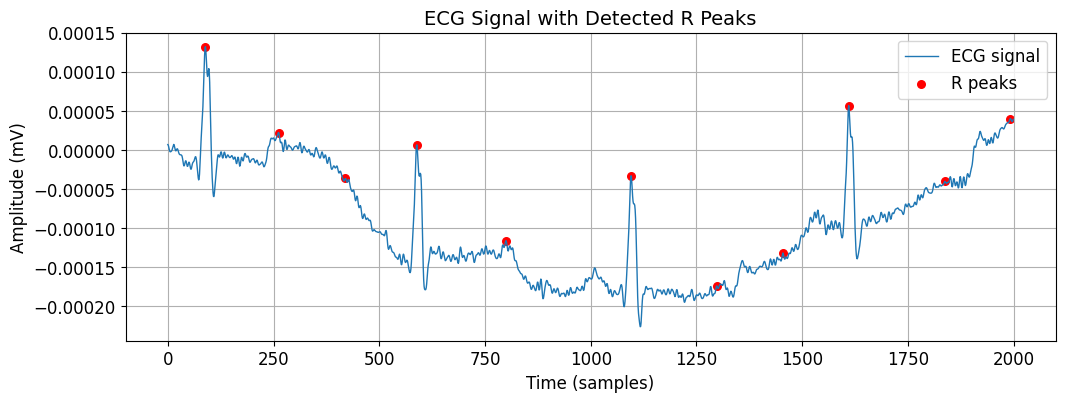

In [82]:
plt.figure(figsize=(12,4))
plt.plot(segment, label="ECG signal", linewidth=1)
plt.scatter(peaks, segment[peaks], color="red", s=30, label="R peaks")
plt.title("ECG Signal with Detected R Peaks")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

**Figure 5:** Detected R peaks in the ECG signal.

The red points indicate local maxima corresponding to heartbeats.

## RR Interval

The **RR interval** represents the time difference between two consecutive R peaks.

If $R_i$ and $R_{i+1}$ represent the times of two consecutive R peaks, the RR interval is:

$$
RR_i = R_{i+1} - R_i
$$

RR intervals are essential for estimating heart rate.

In [83]:
rr_intervals = np.diff(peaks)

## Heart Rate Estimation

Heart rate can be estimated from the RR intervals.

If the sampling frequency is $f_s$, then:

$$
RR_{seconds} = \frac{RR}{f_s}
$$

and the heart rate is:

$$
HR = \frac{60}{RR_{seconds}}
$$

In [84]:
fs = 360  # typical ECG sampling rate
rr_seconds = rr_intervals / fs
heart_rate = 60 / np.mean(rr_seconds)
print("Estimated Heart Rate:", heart_rate)

Estimated Heart Rate: 113.5049921177089


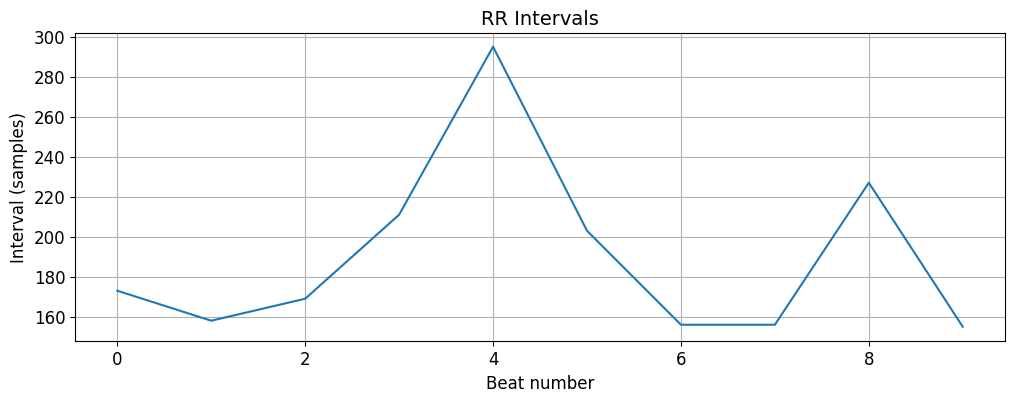

In [85]:
plt.figure(figsize=(12,4))
plt.plot(rr_intervals)
plt.title("RR Intervals")
plt.xlabel("Beat number")
plt.ylabel("Interval (samples)")
plt.show()

**Figure 6:** Zoomed segment of the ECG signal showing RR Intervals.

In [86]:
segment = signal[:2000]
# Apply filtering
filtered = moving_average(segment)

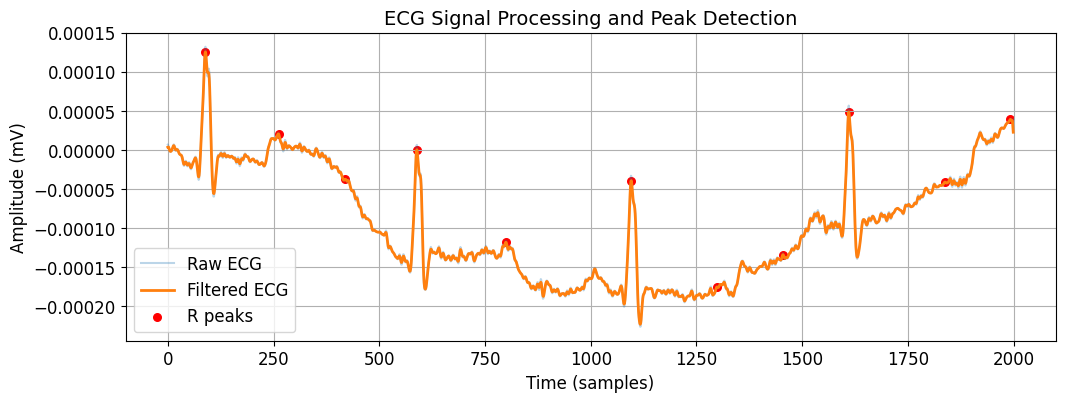

In [87]:
plt.figure(figsize=(12,4))
plt.plot(segment, alpha=0.3, label="Raw ECG")
plt.plot(filtered, linewidth=2, label="Filtered ECG")
plt.scatter(peaks, filtered[peaks], color="red", s=30, label="R peaks")
plt.title("ECG Signal Processing and Peak Detection")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

**Figure 7:** Processed ECG signal with detected R peaks.

The filtered signal allows for more accurate peak detection compared to the raw ECG signal.

## ECG Measurement Setup

## ECG Measurement Setup

Electrocardiography (ECG) signals are recorded using electrodes placed on specific locations on the human body.

The placement of these electrodes is essential for capturing accurate electrical activity of the heart.

![ECG electrode placement](images/ecg_electrode_placement.png)

**Figure:** Standard placement of ECG electrodes on the human body.

Source: https://www.cardiacdirect.com/12-lead-ecg-placement-guide/?srsltid=AfmBOoqPoSlOgyRR8ApYZSAGoMcMU0KLRxAsVS-LArrN2qDblgNvpoK2

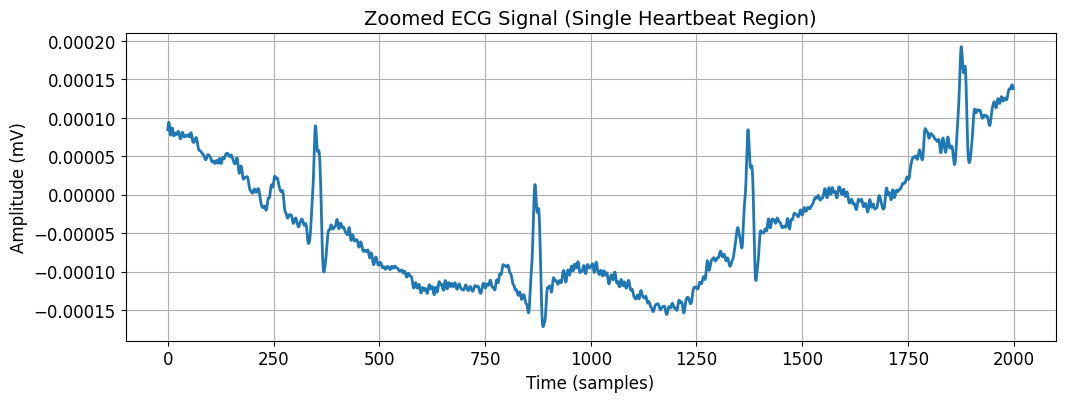

In [88]:
segment_zoom = signal[5000:7000]

plt.figure(figsize=(12,4))

plt.plot(segment_zoom, linewidth=2)

plt.title("Zoomed ECG Signal (Single Heartbeat Region)")

plt.xlabel("Time (samples)")
plt.ylabel("Amplitude (mV)")

plt.show()

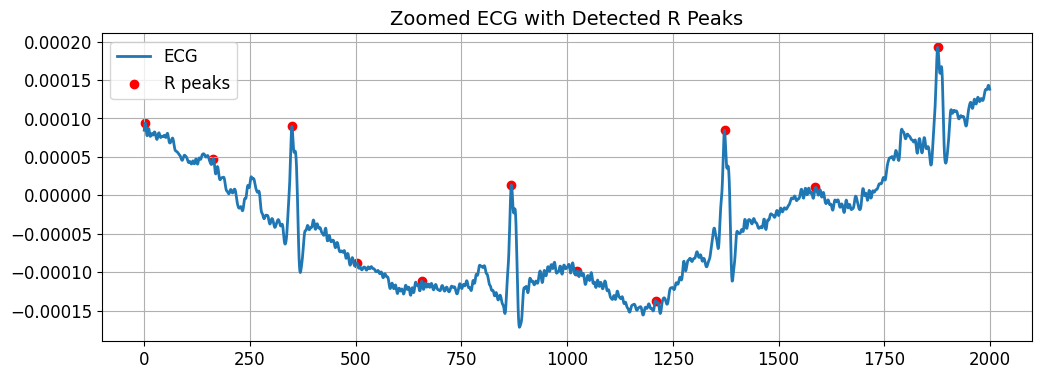

In [89]:
peaks_zoom = detect_r_peaks(segment_zoom)

plt.figure(figsize=(12,4))

plt.plot(segment_zoom, linewidth=2, label="ECG")

plt.scatter(peaks_zoom, segment_zoom[peaks_zoom], color="red", label="R peaks")

plt.title("Zoomed ECG with Detected R Peaks")

plt.legend()

plt.show()

**Figure 8-9:** Zoomed segment of the ECG signal showing individual heartbeats.

The R peaks are clearly visible as local maxima in the signal.

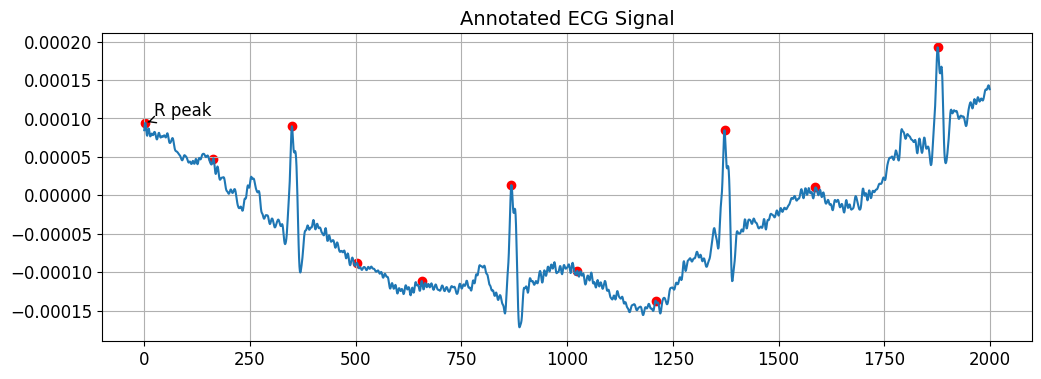

In [90]:
peak_index = peaks_zoom[0]

plt.figure(figsize=(12,4))

plt.plot(segment_zoom)

plt.scatter(peaks_zoom, segment_zoom[peaks_zoom], color="red")

offset_x = 20
offset_y = 0.05 * max(segment_zoom)

plt.annotate(
    "R peak",
    (peak_index, segment_zoom[peak_index]),
    xytext=(peak_index + offset_x, segment_zoom[peak_index] + offset_y),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Annotated ECG Signal")


plt.show()

**Figure 10:** Zoomed segment of the Annotated ECG signal showing individual heartbeats.

The R peaks are clearly visible as local maxima in the signal.

## References

- ECG Fundamentals – medical literature  
- Signal Processing with Python – SciPy documentation  
- Biomedical Signal Analysis resources  
- Public ECG datasets (EDF format)

## Conclusion

In this project, we explored how mathematical concepts from calculus can be applied to the analysis of electrocardiogram (ECG) data.

We demonstrated that the ECG signal can be modeled as a function of time $f(t)$, which allows the use of derivatives and other mathematical tools to analyze its behavior.

By computing the first derivative, we were able to identify regions of rapid change in the signal, particularly during the QRS complex. Furthermore, we showed that R peaks correspond to local maxima, which can be detected algorithmically.

Using this approach, we implemented a method for detecting R peaks and calculating RR intervals. Based on these intervals, we estimated the heart rate, demonstrating a practical application of calculus in medical data analysis.

Additionally, we applied simple noise filtering techniques to improve signal quality and enhance the accuracy of peak detection.

Overall, this project highlights the strong connection between mathematical theory and real-world applications, particularly in the field of biomedical signal analysis.

## Summary of Results

The following key results were obtained:

- Successful visualization of ECG signals from real-world data  
- Application of derivatives to highlight rapid signal changes  
- Detection of R peaks as local maxima  
- Calculation of RR intervals  
- Estimation of heart rate from ECG data  
- Improvement of signal quality using noise filtering

## Limitations

Despite the successful implementation, several limitations should be noted:

- The R peak detection algorithm is relatively simple and may not perform well in noisy or irregular signals  
- A fixed sampling frequency was assumed, which may not be accurate for all datasets  
- The noise filtering method used is basic and may not remove all types of noise  

These limitations suggest that more advanced methods could further improve the analysis.

## Future Work

There are several directions for future improvements:

- Implement more advanced filtering techniques (e.g., band-pass filters)  
- Use more sophisticated peak detection algorithms  
- Analyze multiple ECG recordings for better validation  
- Explore heart rate variability (HRV) analysis  
- Apply machine learning methods for disease detection  

These extensions would make the system more robust and closer to real-world medical applications.